## ViT

In [2]:
import torch
from PIL import Image
from torchvision.models import vision_transformer

from zennit.image import imgify
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

from lxt.efficient import monkey_patch, monkey_patch_zennit

monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched GELU
Patched LayerNorm
Patched MultiheadAttention
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward


In [3]:
from io import BytesIO
import requests

def get_vit_imagenet(device="cuda"):
    """
    Load a pre-trained Vision Transformer (ViT) model with ImageNet weights.

    Parameters:
    device (str): Device to load the model on ('cuda' or 'cpu')

    Returns:
    tuple: (model, weights) - The ViT model and its pre-trained weights
    """
    weights =vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    model = vision_transformer.vit_b_16(weights=weights)
    model.eval()
    model.to(device)

    # Deactivate gradients on parameters to save memory
    for param in model.parameters():
        param.requires_grad = False

    return model, weights

# Load the pre-trained ViT model
model_vit, weights = get_vit_imagenet()

# Load and preprocess the input image
image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")
input_tensor = weights.transforms()(image).unsqueeze(0).to("cuda")

In [4]:
image.size

(2048, 1365)

In [5]:
model_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [6]:
input_tensor.shape

torch.Size([1, 3, 224, 224])

In [7]:
# Define rules for the Conv2d and Linear layers using 'zennit'
conv_gamma = 100
lin_gamma = 0.05
# LayerMapComposite maps specific layer types to specific LRP rule implementations
zennit_comp = LayerMapComposite([
    (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
    (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
])

# Register the composite rules with the model_vit
zennit_comp.register(model_vit)

# Forward pass with gradient tracking enabled
y = model_vit(input_tensor.requires_grad_())

# Get the top 5 predictions
_, top5_classes = torch.topk(y, 5, dim=1)
top5_classes = top5_classes.squeeze(0).tolist()

# Get the class labels
labels = weights.meta["categories"]
top5_labels = [labels[class_idx] for class_idx in top5_classes]

# Print the top 5 predictions and their labels
for i, class_idx in enumerate(top5_classes):
    print(f'Top {i+1} predicted class: {class_idx}, label: {top5_labels[i]}')

# Backward pass for the highest probability class
# This initiates the LRP computation through the network
y[0, top5_classes[0]].backward()

# Remove the registered composite to prevent interference in future iterations
zennit_comp.remove()

# Calculate the relevance by computing Input*Gradient
# This is the final step of LRP to get the pixel-wise explanation
heatmap = (input_tensor * input_tensor.grad).sum(1)

# Normalize relevance between [-1, 1] for plotting
heatmap = heatmap / abs(heatmap).max()

Top 1 predicted class: 176, label: Saluki
Top 2 predicted class: 250, label: Siberian husky
Top 3 predicted class: 207, label: golden retriever
Top 4 predicted class: 248, label: Eskimo dog
Top 5 predicted class: 208, label: Labrador retriever


In [8]:
heatmap.shape

torch.Size([1, 224, 224])

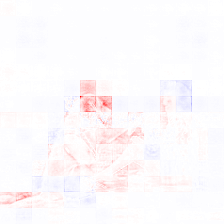

In [9]:
imgify(heatmap.detach().cpu().numpy(), vmin=-1, vmax=1)

## Qwen 3

In [1]:
import torch
from transformers import AutoTokenizer
from transformers.models.qwen3 import modeling_qwen3
from transformers import BitsAndBytesConfig

from lxt.efficient import monkey_patch
from lxt.utils import pdf_heatmap, clean_tokens

# modify the Qwen3 module to compute LRP in the backward pass
monkey_patch(modeling_qwen3, verbose=True)

# optional 4bit quantization 
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

path = 'Qwen/Qwen3-1.7B'
model = modeling_qwen3.Qwen3ForCausalLM.from_pretrained(path,
                                                        device_map='auto',
                                                        dtype=torch.bfloat16,
                                                        quantization_config=quantization_config)


tokenizer = AutoTokenizer.from_pretrained(path)

prompt = """Context: Mount Everest attracts many climbers, including highly experienced mountaineers. There are two main climbing routes, one approaching the summit from the southeast in Nepal (known as the standard route) and the other from the north in Tibet. While not posing substantial technical climbing challenges on the standard route, Everest presents dangers such as altitude sickness, weather, and wind, as well as hazards from avalanches and the Khumbu Icefall. As of November 2022, 310 people have died on Everest. Over 200 bodies remain on the mountain and have not been removed due to the dangerous conditions. The first recorded efforts to reach Everest's summit were made by British mountaineers. As Nepal did not allow foreigners to enter the country at the time, the British made several attempts on the north ridge route from the Tibetan side. After the first reconnaissance expedition by the British in 1921 reached 7,000 m (22,970 ft) on the North Col, the 1922 expedition pushed the north ridge route up to 8,320 m (27,300 ft), marking the first time a human had climbed above 8,000 m (26,247 ft). The 1924 expedition resulted in one of the greatest mysteries on Everest to this day: George Mallory and Andrew Irvine made a final summit attempt on 8 June but never returned, sparking debate as to whether they were the first to reach the top. Tenzing Norgay and Edmund Hillary made the first documented ascent of Everest in 1953, using the southeast ridge route. Norgay had reached 8,595 m (28,199 ft) the previous year as a member of the 1952 Swiss expedition. The Chinese mountaineering team of Wang Fuzhou, Gonpo, and Qu Yinhua made the first reported ascent of the peak from the north ridge on 25 May 1960. \
Question: How high did they climb in 1922? According to the text, the 1922 expedition reached 8,"""

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(model.device)
input_ids = inputs.input_ids


/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched Qwen3MLP
Patched Qwen3RMSNorm
Patched Dropout
Patched transformers.models.qwen3.modeling_qwen3


Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.59s/it]


In [2]:

attention_mask = inputs.attention_mask

with torch.no_grad():
    generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask)
# tokenizer.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]


In [3]:
generated_ids.shape

torch.Size([1, 476])

In [ ]:

gen_ids = generated_ids[:, ctx_len:]          # [1, L_gen]  only the newly generated tokens

tokenizer.batch_decode(gen_ids, skip_special_tokens=False, clean_up_tokenization_spaces=False)[0]


'320 m (27,300 ft). The answer is...?\nA)'

In [6]:
L_gen = gen_ids.size(1)

# positions whose logits predict each generated token
indices = torch.arange(
    ctx_len - 1,
    ctx_len - 1 + L_gen,
    device=model.device
)  # shape [L_gen]


In [9]:
L_gen = gen_ids.size(1)
L_gen

20

In [12]:
# # optional gradient checkpointing to save memory (2x forward pass)
# model.train()
# model.gradient_checkpointing_enable()

# deactive gradients on parameters to save memory
for param in model.parameters():
    param.requires_grad = False


# get input embeddings so that we can compute gradients w.r.t. input embeddings
input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).input_ids.to(model.device)
# input_embeds = model.get_input_embeddings()(input_ids)
input_embeds = model.get_input_embeddings()(generated_ids)

# inference and get the maximum logit at the last position (we can also explain other tokens)
output_logits = model(inputs_embeds=input_embeds.requires_grad_(), use_cache=False).logits


In [13]:
output_logits.shape

torch.Size([1, 476, 151936])

In [14]:
selected_logits = output_logits[0, indices, gen_ids[0]]   # [L_gen]

selected_logits.backward(torch.ones_like(selected_logits))
# equivalently: selected_logits.sum().backward()


In [35]:
# max_logits, max_indices = torch.max(output_logits[0, -1, :], dim=-1)

# # Backward pass (the relevance is initialized with the value of max_logits)
# # This initiates the LRP computation through the network
# max_logits.backward()

# obtain relevance by computing Input * Gradient
relevance = (input_embeds * input_embeds.grad).float().sum(-1).detach().cpu()[0] # cast to float32 before summation for higher precision

# normalize relevance between [-1, 1] for plotting
#relevance = relevance / relevance.abs().max()

In [16]:
# remove special characters from token strings and plot the heatmap
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens = clean_tokens(tokens)

# pdf_heatmap(tokens, relevance, path='qwen3_1.7B_heatmap.pdf', backend='xelatex') # backend='xelatex' supports more characters

# # plot again without first token, because it receives large relevance values overshadowing the rest
# pdf_heatmap(tokens[1:], relevance[1:] / relevance[1:].max(), path='qwen3_1.7B_heatmap_wo_first.pdf', backend='xelatex')

In [36]:
prompt_relevance = relevance[:ctx_len]
prompt_tokens = tokenizer.convert_ids_to_tokens(generated_ids[0, :ctx_len])
prompt_tokens = clean_tokens(prompt_tokens)



In [37]:
import numpy as np
import matplotlib

def _apply_colormap(relevance, cmap_name="bwr"):
    """
    Map a scalar relevance in [-1, 1] to an RGB triplet in [0, 1].
    """
    # normalize from [-1, 1] to [0, 1]
    v = (relevance + 1.0) / 2.0
    v = np.clip(v, 0.0, 1.0)

    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    r, g, b, _ = cmap(v)
    return r, g, b


def _escape_html(text: str) -> str:
    return (
        text.replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
    )

def _generate_html(words, relevances, cmap="bwr"):
    """
    Generate HTML code for a sentence with colored words based on their relevances.
    """
    html = []
    html.append("<!DOCTYPE html>")
    html.append("<html>")
    html.append("<head>")
    html.append('<meta charset="utf-8">')
    html.append("<style>")
    html.append("""
    body {
        font-family: sans-serif;
        max-width: 900px;
        line-height: 1.6;
        padding: 1rem;
    }
    .token {
        padding: 2px 3px;
        margin: 1px 1px;
        display: inline-block;
        font-family: monospace;
        border-radius: 2px;
    }
    """)
    html.append("</style>")
    html.append("</head>")
    html.append("<body>")

    for word, relevance in zip(words, relevances):
        r, g, b = _apply_colormap(float(relevance), cmap)
        R, G, B = int(r * 255), int(g * 255), int(b * 255)

        word_html = _escape_html(word)
        html.append(
            f'<span class="token" '
            f'style="background-color: rgb({R},{G},{B});">'
            f'{word_html}</span>'
        )

    html.append("</body>")
    html.append("</html>")

    return "\n".join(html)


In [38]:
def html_heatmap(words, relevances, path="heatmap.html", cmap="bwr"):
    """
    Write an HTML file with colored tokens according to relevance.
    No LaTeX, no external dependencies beyond matplotlib (for colormap).
    """
    html_code = _generate_html(words, relevances, cmap=cmap)

    with open(path, "w", encoding="utf-8") as f:
        f.write(html_code)

    print(f"Saved HTML heatmap to: {path}")
    return path


In [39]:
from IPython.display import HTML, display


# html_heatmap(prompt_tokens, prompt_relevance,
#             path='qwen3_1.7B_prediction_heatmap.html')
html_code = _generate_html(prompt_tokens, prompt_relevance, cmap="bwr")
display(HTML(html_code))

## Captum LLM

In [1]:
from huggingface_hub import login
login()

In [4]:
import bitsandbytes as bnb
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

def load_model(model_name, bnb_config):
    n_gpus = torch.cuda.device_count()
    max_memory = "10000MB"

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        dtype=torch.bfloat16,
        device_map="cuda",  # dispatch efficiently the model on the available ressources
        #max_memory = {i: max_memory for i in range(n_gpus)},
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, token=True)

    # Needed for LLaMA tokenizer
    # tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

def create_bnb_config():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        # bnb_4bit_use_double_quant=True,
        # bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    return bnb_config

In [5]:
model_name = "Qwen/Qwen3-1.7B" 

bnb_config = create_bnb_config()

model, tokenizer = load_model(model_name, bnb_config)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
from abc import abstractmethod

from torch import nn

class HF_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        raise NotImplementedError

    def forward(self, text_embeds, pixel_values, pixel_mask,
                attention_mask, token_type_ids):
        outs = self.hf_model(inputs_embeds = text_embeds,
                             pixel_values=pixel_values,
                             attention_mask=attention_mask,
                             pixel_mask=pixel_mask,
                             token_type_ids=token_type_ids,
                             )
        return outs.logits

    # --------- device helpers ---------

    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "HF_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self

In [8]:
from captum.attr import (
    LayerIntegratedGradients, 
    LLMGradientAttribution, 
    TextTokenInput, 
    TextTemplateInput,
    ProductBaselines,
)

In [6]:
model.model.embed_tokens

Embedding(151936, 2048)

In [9]:
lig = LayerIntegratedGradients(model, model.model.embed_tokens)

llm_attr = LLMGradientAttribution(lig, tokenizer)

In [10]:
eval_prompt = "Dave lives in Palm Coast, FL and is a lawyer. His personal interests include"
target = "playing guitar, hiking, and spending time with his family."
skip_tokens = [1]  # skip the special token for the start of the text <s>


In [11]:
inp = TextTokenInput(
    eval_prompt,
    tokenizer,
    skip_tokens=skip_tokens,
)

In [ ]:
attr_res = llm_attr.attribute(inp, target=target, skip_tokens=skip_tokens)
attr_res.plot_seq_attr(show=True)

In [ ]:
from typing import List
import torch
from torch import nn, Tensor

def captum_llm_attribution(inpts, target: List[str], model,
                          tokenizer, attr_hf):

    if isinstance(target, list):
        # Encode the target using the preprocessor
        target_tokens = tokenizer(target, return_tensors="pt", add_special_tokens=True).to(model.device)

    elif isinstance(target, torch.Tensor):
        # Move the target to the good device
        target_tokens = target.clone().detach().to(model.device)

    inpts.to(model.device)
    input_ids = inpts.input_ids
    attention_mask = inpts.attention_mask


    # Call the attrubition method

    attr_list = []
    for cur_target_idx, _ in enumerate(target_tokens):
        # attr in shape(batch_size, input+output_len, emb_dim)
        attr = get_llm_attribution(inpts, cur_target_idx, target)

        if cur_target_idx:
            out_token_tensor = target_tokens[:cur_target_idx].unsqueeze(0).expand(input_ids.size(0), -1).to(model.device)

            new_input_ids = torch.cat([input_ids, out_token_tensor], dim=1)
            attention_mask = torch.ones_like(input_ids, device=model.device)

        else:
            new_input_ids = input_ids

        # Get the embeddings
        input_embeds = model.get_inputs_embeddings(new_input_ids).clone().detach()

        output_logits = model(new_input_tensor)

        new_token_logits = output_logits.logits[:, -1]
        log_probs = torch.nn.functional.log_softmax(new_token_logits, dim=1)

        target_token = target_tokens[cur_target_idx]
        token_log_probs = log_probs[..., target_token]




        attr = cast(Tensor, attr)

        # will have the attr for previous output tokens
        # cut to shape(batch_size, inp_len, emb_dim)
        if cur_target_idx:
            attr = attr[:, :-cur_target_idx]

        # the author of IG uses sum
        # https://github.com/ankurtaly/Integrated-Gradients/blob/master/BertModel/bert_model_utils.py#L350
        attr = attr.sum(-1)

        attr_list.append(attr)

    # assume inp batch only has one instance
    # to shape(n_output_token, ...)
    attr = torch.cat(attr_list, dim=0)

    # grad attr method do not care the length of features in interpretable format
    # it attributes to all the elements of the output of the specified layer
    # so we need special handling for the inp type which don't care all the elements
    if isinstance(inp, TextTokenInput) and inp.itp_mask is not None:
        itp_mask = inp.itp_mask.to(attr.device)
        itp_mask = itp_mask.expand_as(attr)
        attr = attr[itp_mask].view(attr.size(0), -1)

    # for all the gradient methods we support in this class
    # the seq attr is the sum of all the token attr if the attr_target is log_prob,
    # shape(n_input_features)
    seq_attr = attr.sum(0)


## Qwen VL


In [1]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from transformers.utils.import_utils import is_flash_attn_2_available

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

def load_qwen_model(model_id="Qwen/Qwen2.5-VL-3B-Instruct"):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

    processor = AutoProcessor.from_pretrained(model_id)

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype=torch.bfloat16,          # keep weights in fp16 after dequant chunks
        device_map="cuda",                  # split across GPU/CPU automatically
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=None,
    )
    return model, processor


/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.41s/it]


Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [3]:
processor

Qwen2_5_VLProcessor:
- image_processor: Qwen2VLImageProcessorFast {
  "crop_size": null,
  "data_format": "channels_first",
  "default_to_square": true,
  "device": null,
  "disable_grouping": null,
  "do_center_crop": null,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_pad": null,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "Qwen2VLImageProcessorFast",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "input_data_format": null,
  "max_pixels": 12845056,
  "merge_size": 2,
  "min_pixels": 3136,
  "pad_size": null,
  "patch_size": 14,
  "processor_class": "Qwen2_5_VLProcessor",
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "return_tensors": null,
  "size": {
    "longest_edge": 12845056,
    "shortest_edge": 3136
  },
  "temporal_patch_size": 2
}

- tokenizer: Qwen2TokenizerFast(name_or_path='Qwen/Qwen2.5-VL-3B-Instruct', vocab_size=151643, model_max

In [4]:
model.config

Qwen2_5_VLConfig {
  "architectures": [
    "Qwen2_5_VLForConditionalGeneration"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "image_token_id": 151655,
  "initializer_range": 0.02,
  "intermediate_size": 11008,
  "max_position_embeddings": 128000,
  "max_window_layers": 70,
  "model_type": "qwen2_5_vl",
  "num_attention_heads": 16,
  "num_hidden_layers": 36,
  "num_key_value_heads": 2,
  "quantization_config": {
    "_load_in_4bit": true,
    "_load_in_8bit": false,
    "bnb_4bit_compute_dtype": "bfloat16",
    "bnb_4bit_quant_storage": "uint8",
    "bnb_4bit_quant_type": "fp4",
    "bnb_4bit_use_double_quant": false,
    "llm_int8_enable_fp32_cpu_offload": false,
    "llm_int8_has_fp16_weight": false,
    "llm_int8_skip_modules": null,
    "llm_int8_threshold": 6.0,
    "load_in_4bit": true,
    "load_in_8bit": false,
    "quant_method": "bitsandbytes"
  },
  "rms_norm_eps":

In [5]:
print(model.language_model)

Qwen2_5_VLTextModel(
  (embed_tokens): Embedding(151936, 2048)
  (layers): ModuleList(
    (0-35): 36 x Qwen2_5_VLDecoderLayer(
      (self_attn): Qwen2_5_VLAttention(
        (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=True)
        (k_proj): Linear4bit(in_features=2048, out_features=256, bias=True)
        (v_proj): Linear4bit(in_features=2048, out_features=256, bias=True)
        (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
        (rotary_emb): Qwen2_5_VLRotaryEmbedding()
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear4bit(in_features=2048, out_features=11008, bias=False)
        (up_proj): Linear4bit(in_features=2048, out_features=11008, bias=False)
        (down_proj): Linear4bit(in_features=11008, out_features=2048, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm

In [6]:
print(model.visual)

Qwen2_5_VisionTransformerPretrainedModel(
  (patch_embed): Qwen2_5_VisionPatchEmbed(
    (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
  )
  (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x Qwen2_5_VLVisionBlock(
      (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
      (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
      (attn): Qwen2_5_VLVisionAttention(
        (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
        (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
      )
      (mlp): Qwen2_5_VLMLP(
        (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
        (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
        (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        (act_fn): SiLUActivation()
      )
    )
  )
  (merger): Qwen2_5_VLPatchMerger(
    (ln_q): Qwen2RMSNorm((1280,), eps=1e-06)
    (mlp): Sequen

In [ ]:
from datasets import load_dataset

dataset = load_dataset("lmms-lab/DocVQA", 'DocVQA', split="validation[:10]")

In [ ]:


print(f"\nStarting evaluation on {len(dataset)} document samples...\n")

for i, sample in enumerate(dataset):
    image = sample["image"]
    question = sample["question"]
    
    # DocVQA answers are typically a list of strings
    ground_truths = sample["answers"]

    # Prepare prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": f"{question}"} 
            ],
        }
    ]

    # Preprocess
    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text_input],
        images=[image],
        padding=True,
        return_tensors="pt",
    ).to(DEVICE)

In [7]:
from PIL import Image
import requests
from io import BytesIO

from qwen_vl_utils import process_vision_info

def get_inputs(processor, dtype=torch.bfloat16):
    image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
    image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")

    # Construct the multimodal conversation prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                # {"type": "text", "text": "Describe the main scene and the object being pointed at."},
                {"type": "text", "text": "What is the color of the dog ?"},
            ],
        }
    ]

    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

     # ---- Convert everything that can be bf16 into bf16 ----
    if dtype is not None:
        for k in inputs:
            if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
                inputs[k] = inputs[k].to(dtype=dtype)


    return inputs, image


In [8]:
inputs, image = get_inputs(processor)

In [9]:
inputs = inputs.to(model.device)

In [ ]:
def get_target(inputs, model):
    inputs = inputs.to("cuda")
    model.eval()
    with torch.no_grad():

        gen_ids = model.generate(**inputs,
                                max_new_tokens=32,
                                use_cache=False)

    return gen_ids


In [11]:
gen_ids = get_target(inputs, model)

In [12]:
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, gen_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

['The dog in the picture is yellowish-brown in color.']


In [13]:
generated_ids_trimmed[0].shape

torch.Size([14])

In [14]:
gen_ids.shape

torch.Size([1, 3620])

In [15]:
input_ids = inputs["input_ids"]
ctx_len = input_ids.size(1)

gen_ids_new = gen_ids[:, ctx_len:]          # [1, L_gen]  only the newly generated tokens

processor.batch_decode(gen_ids_new, skip_special_tokens=False, clean_up_tokenization_spaces=False)[0]


'The dog in the picture is yellowish-brown in color.<|im_end|>'

In [16]:
L_gen = gen_ids_new.size(1)

# positions whose logits predict each generated token
indices = torch.arange(
    ctx_len - 1,
    ctx_len - 1 + L_gen,
    device=model.device
)  # shape [L_gen]


In [17]:
indices

tensor([3605, 3606, 3607, 3608, 3609, 3610, 3611, 3612, 3613, 3614, 3615, 3616,
        3617, 3618], device='cuda:0')

In [13]:
torch.cuda.empty_cache()

In [10]:
from torchinfo import summary

summary(model.visual, input_data=(
                        #inputs["input_ids"],
                           #inputs["attention_mask"], 
                           inputs["pixel_values"], 
                           inputs["image_grid_thw"]
                           ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                             Output Shape              Param #
Qwen2_5_VisionTransformerPretrainedModel           [3577, 2048]              --
├─Qwen2_5_VisionPatchEmbed: 1-1                    [14308, 1280]             --
│    └─Conv3d: 2-1                                 [14308, 1280, 1, 1, 1]    1,505,280
├─Qwen2_5_VisionRotaryEmbedding: 1-2               [146, 20]                 --
├─ModuleList: 1-3                                  --                        --
│    └─Qwen2_5_VLVisionBlock: 2-2                  [14308, 1280]             --
│    │    └─Qwen2RMSNorm: 3-1                      [14308, 1280]             1,280
│    │    └─Qwen2_5_VLVisionAttention: 3-2         [14308, 1280]             --
│    │    │    └─Linear: 4-1                       [14308, 3840]             4,919,040
│    │    │    └─Linear: 4-2                       [14308, 1280]             1,639,680
│    │    └─Qwen2RMSNorm: 3-3                      [14308, 1280]             1,280
│    │  

In [11]:
from torchinfo import summary

summary(model.language_model, input_data=(
                                inputs["input_ids"],
                                inputs["attention_mask"], 
                                #inputs["pixel_values"], 
                                #inputs["image_grid_thw"]
                                ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                        Output Shape              Param #
Qwen2_5_VLTextModel                           [[1]]                     --
├─Embedding: 1-1                              [1, 3609, 2048]           311,164,928
├─Qwen2_5_VLRotaryEmbedding: 1-2              [3, 1, 3609, 128]         --
├─ModuleList: 1-3                             --                        --
│    └─Qwen2_5_VLDecoderLayer: 2-1            [1, 1, 2048]              --
│    │    └─Qwen2RMSNorm: 3-1                 [1, 3609, 2048]           2,048
│    │    └─Qwen2_5_VLAttention: 3-2          [1, 1, 2048]              --
│    │    │    └─Linear: 4-1                  [1, 3609, 2048]           4,196,352
│    │    │    └─Linear: 4-2                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-3                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-4                  [1, 3609, 2048]           4,194,304
│    │    └─Qwen2RMSNorm: 3-3                 [1, 3609, 204

In [12]:
model

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLUAc

In [44]:
from torchinfo import summary

summary(model, input_data=(
                        inputs["input_ids"],
                        #inputs["attention_mask"], 
                        inputs["pixel_values"], 
                        #inputs["image_grid_thw"]
                        ),
                batch_dim=1,
        #depth=5
        )

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Embedding: 3]

### LXT

In [14]:
from functools import partial
from torch.nn import Dropout
# from transformers.models.qwen2 import modeling_qwen2
# from transformers.models.qwen2.modeling_qwen2 import Qwen2MLP, Qwen2RMSNorm

from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLMLP
from transformers.models.qwen2.modeling_qwen2 import Qwen2RMSNorm

from lxt.efficient.patches import patch_method, patch_attention, patch_cp_attention
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, cp_gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit

from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

def configure_lxt(model, use_zennit=False):

    attnLRP = {
        Qwen2_5_VLMLP: partial(patch_method, gated_mlp_forward),
        Qwen2RMSNorm: partial(patch_method, rms_norm_forward), 
        Dropout: partial(patch_method, dropout_forward),
        modeling_qwen2_5_vl: patch_attention,
    }

    monkey_patch(modeling_qwen2_5_vl, patch_map=attnLRP, verbose=True)

    zennit_comp = None

    if use_zennit:
        # Define rules for the Conv2d and Linear layers using 'zennit'
        conv_gamma = 100
        lin_gamma = 0.05
        # LayerMapComposite maps specific layer types to specific LRP rule implementations
        zennit_comp = LayerMapComposite([
            (torch.nn.Conv3d, z_rules.Gamma(conv_gamma)),
            (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
        ])
        
        monkey_patch_zennit(verbose=True)

    # Set up the model for the explanation task
    # model.train()  # Switch to train mode to enable  gradient flow
    #model.gradient_checkpointing_enable()  # Optional: saves memory

    # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
    for param in model.parameters():
        param.requires_grad = False

    if zennit_comp is not None:
        # Register the composite rules with the model
        zennit_comp.register(model)
    return zennit_comp


In [15]:
# from zennit.composites import LayerMapComposite
# import zennit.rules as z_rules

# # Define rules for the Conv2d and Linear layers using 'zennit'
# conv_gamma = 100
# lin_gamma = 0.05
# # LayerMapComposite maps specific layer types to specific LRP rule implementations
# zennit_comp = LayerMapComposite([
#     (torch.nn.Conv3d, z_rules.Gamma(conv_gamma)),
#     (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
# ])

In [16]:
zennit_comp = configure_lxt(model, use_zennit=False)

Patched Qwen2_5_VLMLP
Patched Qwen2RMSNorm
Patched Dropout
Patched transformers.models.qwen2_5_vl.modeling_qwen2_5_vl


In [22]:
torch.cuda.empty_cache()


#### Text attribution

In [18]:
def get_relevance(model, inputs, zennit_comp=None, gen_ids=None,
                  full_relevance=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw

    if gen_ids is not None:
        ctx_len = input_ids.size(1)
        gen_ids_new = gen_ids[:, ctx_len:]
        L_gen = gen_ids_new.size(1)
        input_ids = torch.cat([input_ids, gen_ids_new], dim=1)
        attention_mask = torch.ones_like(input_ids, device=model.device)

    # Text embeddings
    text_embeds = model.get_input_embeddings()(input_ids).clone().detach()
    if full_relevance:
        text_embeds.requires_grad_(True) # .to(model.device)


    # Vision embeddings
    pixel_values = pixel_values.clone().detach()
    if full_relevance:
        pixel_values.requires_grad_(True)
    image_embeds = model.get_image_features(pixel_values,
                                            image_grid_thw=image_grid_thw)
    
    image_embeds = torch.cat(image_embeds, dim=0).to(text_embeds.device, text_embeds.dtype)
    image_mask, _ = model.model.get_placeholder_mask(
        input_ids, inputs_embeds=text_embeds, image_features=image_embeds
    )
    inputs_embeds = text_embeds.masked_scatter(image_mask, image_embeds)

    if not full_relevance:
        inputs_embeds = inputs_embeds.detach().requires_grad_(True)

    # inference and get the maximum logit at the last position (we can also explain other tokens)
    outputs = model(
                    #input_ids=input_ids,
                    inputs_embeds=inputs_embeds,
                    attention_mask=attention_mask,
                    #image_grid_thw=image_grid_thw,
                    #pixel_values=pixel_values,
                    #position_ids=position_ids,
                    use_cache=False
                    )
    
    output_logits = outputs["logits"]

    if gen_ids is not None:
        L_gen = gen_ids_new.size(1)
        
        # positions whose logits predict each generated token
        indices = torch.arange(
            ctx_len - 1,
            ctx_len - 1 + L_gen,
            device=model.device
        )  # shape [L_gen]

        selected_logits = output_logits[0, indices, gen_ids_new[0]]   # [L_gen]
        selected_logits.backward(torch.ones_like(selected_logits))
    else:
        max_logits, _ = torch.max(output_logits[0, -1, :], dim=-1)
        max_logits.backward()

    if zennit_comp is not None:
        # Remove the registered composite to prevent interference in future iterations
        zennit_comp.remove()

    if full_relevance:
        relevance_img = (pixel_values.grad * pixel_values).float().sum(-1).detach().cpu()
        #relevance_img_norm = relevance_img / relevance_img.abs().max()

        relevance_text = (text_embeds.grad * text_embeds).float().sum(-1).detach().cpu()[0]
        #relevance_text_norm = relevance_text / relevance_text.abs().max()
        return relevance_img, relevance_text
    else:
        relevance = (inputs_embeds.grad * inputs_embeds).float().sum(-1).detach().cpu()[0]
        return relevance, relevance

       

In [52]:
full_relevance = True
if full_relevance:
    relevance_img, \
        relevance_text = get_relevance(model,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    gen_ids=None)
else:
    relevance_img = None
    relevance_text, _ = get_relevance(model,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    gen_ids=None)

In [54]:
relevance_img.sum()

tensor(0.3298)

In [55]:
relevance_text.sum()

tensor(-16.3619)

In [ ]:
# image_grid_thw: (B, 3) tensor from the processor

image_grid_thw = inputs["image_grid_thw"]

img_idx = 0
grid_t, grid_h, grid_w = image_grid_thw[img_idx].tolist()  # e.g. [1, H_patches, W_patches]

# relevance: (N,) = (grid_t * grid_h * grid_w,)
relevance_patches = relevance_img.view(grid_t, grid_h, grid_w)

relevance_map = relevance_patches[0]      # (grid_h, grid_w)
patch_size = processor.image_processor.patch_size

resized_height = grid_h * patch_size
resized_width  = grid_w * patch_size

import torch.nn.functional as F

# (H_patches, W_patches) -> (1,1,H_patches,W_patches)
relevance_map_2d = relevance_map.unsqueeze(0).unsqueeze(0)

# Upsample to resized image size
heatmap_resized = F.interpolate(
    relevance_map_2d,
    size=(resized_height, resized_width),
    mode="bilinear",
    align_corners=False,
)  # shape: (1,1,resized_height,resized_width)

heatmap_resized = heatmap_resized.squeeze(0).squeeze(0)  # (resized_height, resized_width)



In [56]:
torch.cuda.empty_cache()

In [57]:
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def reshape_visual_relevance(model, processor, image_size):

    patch_size = processor.image_processor.patch_size
    spatial_merge_size = model.config.vision_config.spatial_merge_size

    height_new, width_new = smart_resize(
        width=image_size[0],
        height=image_size[1],
        factor=patch_size * processor.image_processor.merge_size,
        min_pixels=processor.image_processor.size["shortest_edge"],
        max_pixels=processor.image_processor.size["longest_edge"],
    )


    n_patches_x = width_new // patch_size // spatial_merge_size
    n_patches_y = height_new // patch_size // spatial_merge_size
    return (n_patches_x, n_patches_y)


def visualize_image_relevance(image, img_relevance, figsize=(8,8), save_path=None):


    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    similarity_map_image = Image.fromarray((img_relevance.cpu().numpy() * 255).astype("uint8")).resize(
            image.size, Image.Resampling.BICUBIC
    )
    # similarity_map_image = Image.fromarray(img_relevance.cpu().numpy()).resize(
    #         image.size, Image.Resampling.BICUBIC
    # )
    
    show_colorbar = False
    # Create the figure
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            similarity_map_image,
            cmap=sns.color_palette("bwr", as_cmap=True),
            alpha=0.5,
        )

        if show_colorbar:
            fig.colorbar(im)
        ax.set_axis_off()
        fig.tight_layout()

        # ---- SAVE FIGURE ----
        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_image_relevance_(image, img_relevance, figsize=(8, 8), save_path=None):
    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    # img_relevance: torch.Tensor of shape (H_patches, W_patches), values in [-1, 1]
    rel = img_relevance.cpu().numpy().astype("float32")  # (Hp, Wp)
    similarity_map_image = Image.fromarray(rel, mode="F").resize(
        image.size, Image.Resampling.BICUBIC
    )
    print(similarity_map_image.size)

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            np.array(similarity_map_image),
            cmap="bwr",
            alpha=0.5,
            vmin=-1,
            vmax=1,
        )

        ax.set_axis_off()
        fig.tight_layout()

        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_text_relevance(text, token_relevance, figsize=(8,8), save_path=None):

    # "Importance": abs by default (signed scores → magnitude)
    idx_max = int(torch.argmax(token_relevance))

    # Keep it readable: show top-k (optional)
    k = min(30, len(text))
    top_idx = torch.topk(token_relevance, k).indices.tolist()[::-1]  # highest → lowest
    top_text = [text[i] for i in top_idx]
    top_imp    = token_relevance[top_idx].numpy()

    # Colors: grey for all, one highlighted
    colors = ['lightgray'] * k
    colors[top_idx.index(idx_max)] = 'tab:red'  # color only the most important

    plt.figure(figsize=figsize)
    y = np.arange(k)
    plt.barh(y, top_imp, color=colors)
    plt.yticks(y, top_text)
    plt.gca().invert_yaxis()
    plt.xlabel('Token importance (|relevance|)')
    plt.title('Top-k token attributions (max highlighted)')
    plt.tight_layout()
    # ---- SAVE FIGURE ----
    if save_path is None:
        save_path = "relevance_prompt_overlay.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")



In [58]:
relevance_text_norm = relevance_text / relevance_text.abs().max()
if full_relevance:
    relevance_img_norm = relevance_img / relevance_img.abs().max()
else:
    relevance_img_norm = None

In [42]:
inputs["input_ids"].shape

torch.Size([1, 3606])

In [43]:
relevance_text_norm.shape

torch.Size([3606])

In [64]:
from einops import rearrange

def prepare_relevance_for_visualization(input_ids, image, processor,
                                        image_grid_thw,
                                        relevance_text_norm,
                                        relevance_img_norm=None):
    img_mask = (input_ids == processor.image_token_id)
    token_mask = (input_ids != processor.image_token_id)
    img_mask = img_mask.cpu()
    token_mask = token_mask.cpu()

    idx = 0
    image_size = image.size
    n_patches = reshape_visual_relevance(model, processor, image_size)

    if relevance_img_norm is None:
        patch_relevance = rearrange(
                            relevance_text_norm[img_mask[idx]],  # (n_patches_x * n_patches_y, dim)
                            "(h w) -> w h",
                            w=n_patches[0],
                            h=n_patches[1],
                        )  # (n_patches_x, n_patches_y, dim)
        
    else:
        assert(relevance_text_norm[img_mask[idx]].sum().cpu().numpy() == 0)


        # image_grid_thw: (B, 3) tensor from the processor
        grid_t, grid_h, grid_w = image_grid_thw[idx].tolist()  # e.g. [1, H_patches, W_patches]

        # relevance: (N,) = (grid_t * grid_h * grid_w,)
        patch_relevance = relevance_img_norm.view(grid_t, grid_h, grid_w)

    ids = input_ids[idx][token_mask[idx]]
    token_relevance = relevance_text_norm[token_mask[idx]]

    prompt_text = processor.batch_decode(
        ids, skip_special_tokens=False, clean_up_tokenization_spaces=True
    )

    return token_relevance, patch_relevance, prompt_text


In [65]:
relevance_text_norm.shape

torch.Size([3606])

In [66]:
input_ids.shape

torch.Size([1, 3606])

In [67]:
input_ids = inputs["input_ids"]
image_grid_thw = inputs["image_grid_thw"]

use_target = False
if use_target:
    ctx_len = input_ids.size(1)
    gen_ids_new = gen_ids[:, ctx_len:]
    input_ids = torch.cat([input_ids, gen_ids_new], dim=1)

token_relevance, \
patch_relevance, \
prompt_text = prepare_relevance_for_visualization(input_ids,
                                                image,
                                                processor,
                                                image_grid_thw,
                                                relevance_text_norm,
                                                relevance_img_norm=relevance_img_norm)

In [75]:
full_relevance

True

In [76]:
patch_relevance.sum()

tensor(1.0861)

In [73]:
visualize_image_relevance(image, patch_relevance[0])


In [49]:
visualize_text_relevance(prompt_text, token_relevance)

In [17]:
image.size

(2048, 1365)

In [52]:
from IPython.display import display, HTML

# --- Assume you have your 'tokens' list and 'relevance' tensor ---

def colorize_tokens(tokens, scores):
    """Generates an HTML string with colored token backgrounds."""
    html_string = ""
    # Normalize scores for color mapping
    scores = torch.from_numpy(np.array(scores))
    scores = scores / scores.abs().max()

    for token, score in zip(tokens, scores):
        # Use blue for positive relevance, red for negative
        if score > 0:
            # Alpha (opacity) is proportional to the score
            color = f"rgba(0, 0, 255, {score:.2f})"
        else:
            # Use the absolute value for opacity
            color = f"rgba(255, 0, 0, {abs(score):.2f})"

        # Add a space after each token for readability
        html_string += f'<span style="background-color: {color};">{token}</span> '

    return html_string

# Generate the HTML
html_output = colorize_tokens(output_text, text_relevance_for_heatmap)

# Display it in the notebook
print("Token Relevance:")
display(HTML(html_output))

Token Relevance:


## ColQwen

In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from datasets import load_dataset
from qwen_vl_utils import process_vision_info
import Levenshtein
import string
import re

# -----------------------------------------------------------------------------
# 1. METRIC: ANLS (Average Normalized Levenshtein Similarity)
# -----------------------------------------------------------------------------
def get_anls(prediction, ground_truth):
    """
    Calculates ANLS between a prediction and a single ground truth string.
    Formula: 1 - (distance / max_length)
    Threshold: If score < 0.5, return 0.0
    """
    prediction = prediction.lower().strip()
    ground_truth = ground_truth.lower().strip()
    
    if not prediction and not ground_truth:
        return 1.0
    if not prediction or not ground_truth:
        return 0.0
        
    dist = Levenshtein.distance(prediction, ground_truth)
    max_len = max(len(prediction), len(ground_truth))
    
    score = 1.0 - (dist / max_len)
    
    # ANLS threshold: predictions with < 50% similarity get 0 points
    if score < 0.5:
        return 0.0
    return score

def compute_max_anls(prediction, ground_truth_list):
    """
    DocVQA provides multiple acceptable answers (e.g. ['2023', '2023.']).
    We take the BEST score among all ground truths.
    """
    scores = [get_anls(prediction, gt) for gt in ground_truth_list]
    return max(scores) if scores else 0.0

# -----------------------------------------------------------------------------
# 2. MODEL SETUP
# -----------------------------------------------------------------------------
# Using Qwen2-VL-2B for efficiency. 
# DocVQA images are often tall/wide documents, so we allow higher resolution.
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {MODEL_ID} on {DEVICE}...")

# min_pixels/max_pixels are crucial for Documents to ensure text is readable
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, 
    torch_dtype="auto", 
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=1280*28*28)

# -----------------------------------------------------------------------------
# 3. DATASET LOADING
# -----------------------------------------------------------------------------
# "lmms-lab/DocVQA" is a clean version of the dataset often used for VL evaluations
print("Loading DocVQA dataset (validation subset)...")
dataset = load_dataset("lmms-lab/DocVQA", split="validation[:10]")

# -----------------------------------------------------------------------------
# 4. EVALUATION LOOP
# -----------------------------------------------------------------------------
anls_scores = []

print(f"\nStarting evaluation on {len(dataset)} document samples...\n")

for i, sample in enumerate(dataset):
    image = sample["image"]
    question = sample["question"]
    
    # DocVQA answers are typically a list of strings
    ground_truths = sample["answers"]

    # Prepare prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": f"{question}"} 
            ],
        }
    ]

    # Preprocess
    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text_input],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(DEVICE)

    # Generate
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=50) # Docs might need longer answers
        
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    prediction = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    # Compute Score
    score = compute_max_anls(prediction, ground_truths)
    anls_scores.append(score)

    # -------------------------------------------------------------------------
    # LOGGING
    # -------------------------------------------------------------------------
    print(f"Sample {i+1}:")
    print(f"  Question: {question}")
    print(f"  Prediction: '{prediction}'")
    print(f"  Ground Truths: {ground_truths}")
    print(f"  ANLS Score: {score:.4f}")
    print("-" * 40)

# -----------------------------------------------------------------------------
# 5. FINAL RESULTS
# -----------------------------------------------------------------------------
avg_anls = sum(anls_scores) / len(anls_scores)
print(f"\nEvaluation Complete.")
print(f"Average ANLS: {avg_anls:.4f} (0.0 to 1.0)")

In [1]:
import torch
from PIL import Image
from transformers.utils.import_utils import is_flash_attn_2_available

from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor

In [2]:


model = ColQwen2_5.from_pretrained(
        "vidore/colqwen2.5-v0.2",
        torch_dtype=torch.bfloat16,
        device_map="cuda:0",  # or "mps" if on Apple Silicon
        attn_implementation=None, #"flash_attention_2" if is_flash_attn_2_available() else None,
    ).eval()
processor = ColQwen2_5_Processor.from_pretrained("vidore/colqwen2.5-v0.2")



Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
import mteb

tasks = mteb.get_tasks(tasks=["VidoreArxivQARetrieval"], task_types=["DocumentUnderstanding"], modalities=["text", "image"], languages=['eng'])

In [4]:
task = tasks[0]
task.load_data()             # ensure data is present

corpus = task.corpus["test"]
queries = task.queries["test"]   # dict[qid] -> text

In [35]:
images = [corpus[i]["image"] for i in range (1)]
quest = [queries[i]["text"] for i in range (1)]

In [36]:
quest[0]

'Based on the graph, what is the impact of correcting for fspec not equal to 1 on the surface density trend?'

In [37]:
# Process the inputs
batch_images = processor.process_images(images).to(model.device)
batch_queries = processor.process_queries(quest).to(model.device)


In [44]:
# Forward pass
with torch.no_grad():
    image_embeddings = model(**batch_images)
    query_embeddings = model(**batch_queries)

scores = processor.score_multi_vector(query_embeddings, image_embeddings)

/home/jky/.conda/envs/jky-vdoc/lib/python3.11/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [45]:
scores

tensor([[27.7500]])

In [77]:
print(model.visual)

Qwen2_5_VisionTransformerPretrainedModel(
  (patch_embed): Qwen2_5_VisionPatchEmbed(
    (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
  )
  (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x Qwen2_5_VLVisionBlock(
      (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
      (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
      (attn): Qwen2_5_VLVisionAttention(
        (qkv): Linear(in_features=1280, out_features=3840, bias=True)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (mlp): Qwen2_5_VLMLP(
        (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
        (act_fn): SiLU()
      )
    )
  )
  (merger): Qwen2_5_VLPatchMerger(
    (ln_q): Qwen2RMSNorm((1280,), eps=1e-06)
    (mlp): Sequential(
      (0): Linear(in_fea

## XAI methods

In [ ]:
text_tokens = []
text_relevance_scores = []
image_patch_relevance_scores = []

input_ids_list = inputs['input_ids'][0].tolist()
relevance_list = relevance.tolist()
image_token_id = processor.tokenizer.image_token_id

patch_index = 0
for i, token_id in enumerate(input_ids_list):
    current_relevance = relevance_list[i]
    
    if token_id == image_token_id:
        # This is an image patch
        image_patch_relevance_scores.append((patch_index, current_relevance))
        
        # For visualization, you might want a placeholder
        text_tokens.append(f"[PATCH_{patch_index}]")
        text_relevance_scores.append(current_relevance)
        patch_index += 1
        
    else:
        # This is a text token
        token_str = processor.tokenizer.decode([token_id])
        text_tokens.append(token_str)
        text_relevance_scores.append(current_relevance)

# 1. For text attribution:
# You can now plot the text relevance just like in the example
print("Text Attributions:")
for token, score in zip(text_tokens, text_relevance_scores):
    print(f"{token}: {score:.4f}")

# You can use `pdf_heatmap` with `text_tokens` and `text_relevance_scores`
# pdf_heatmap(text_tokens, text_relevance_scores, path='qwen_vl_heatmap.pdf')


# 2. For image attribution:
# `image_patch_relevance_scores` is a list of (index, relevance) tuples
# The indices 0, 1, 2... correspond to the image patches in order.
print("\nImage Patch Attributions:")
print(image_patch_relevance_scores)

# To visualize this, you must reshape the 1D patch relevance list
# back into the 2D grid of the vision transformer.
# Example: If the vision tower uses 14x14 patches (num_patches=196)
num_patches = len(image_patch_relevance_scores)
grid_size = int(num_patches**0.5) # Assumes a square grid

if grid_size * grid_size == num_patches:
    image_heatmap = torch.zeros(grid_size, grid_size)
    for idx, score in image_patch_relevance_scores:
        row = idx // grid_size
        col = idx % grid_size
        image_heatmap[row, col] = score
    
    # You can now plot this `image_heatmap` (e.g., using matplotlib)
    # and overlay it on the original image.
    print(f"\nImage Relevance Grid ({grid_size}x{grid_size}):")
    print(image_heatmap)
else:
    print("\nCould not determine a square grid for image patch visualization.")

In [ ]:
model.forward()

## LXT

## Attention Rollout

### Draft

In [ ]:
import torch
from torch.nn.modules import Module
from zennit.attribution import Attributor
from zennit.composites import LayerMapComposite
from zennit.core import RemovableHandleList, RemovableHandle, Hook

# --- DEPENDENCY CLASSES (from previous prompts) ---

class HookWithKwargs(Hook):
    '''Base class for hooks that supports kwargs in forward hooks.'''
    def __init__(self):
        super().__init__()
        self.stored_kwargs = None
    
    def pre_forward(self, module, input, kwargs):
        return super().pre_forward(module, input), kwargs

    def forward(self, module, input, kwargs, output):
        '''Forward hook to save module in-/outputs.'''
        self.stored_tensors['input'] = input
        self.stored_kwargs = kwargs

    def register(self, module):
        '''Register this instance by registering all hooks to the supplied module.'''
        return RemovableHandleList([
            RemovableHandle(self),
            module.register_forward_pre_hook(self.pre_forward, with_kwargs=True),
            module.register_forward_hook(self.post_forward),
            module.register_forward_hook(self.forward, with_kwargs=True),
        ])

class HFSavingAttention(HookWithKwargs):
    """
    Hook for Hugging Face attention modules. Saves the attention weights,
    which are assumed to be the second element of the module's output tuple.
    """
    def __init__(self, saved_name: str = "attn_output_weights"):
        super().__init__()
        self.saved_name = saved_name

    def forward(self, module, input, kwargs, output):
        # HF attention modules typically return (hidden_states, attention_probs, ...)
        # We save the attention_probs at index 1.
        self.stored_tensors[self.saved_name] = output[1]



In [ ]:
 #--- THE NEW, IMPROVED ATTRIBUTOR ---

class HFAttentionAttributorV2(Attributor):
    """
    An Attributor for Hugging Face models that accept a dictionary of keyword arguments.
    """
    def __init__(self, model: Module, hf_attention_modules: tuple):
        layer_map = [
            (module_class, HFSavingAttention())
            for module_class in hf_attention_modules
        ]
        composite = LayerMapComposite(layer_map=layer_map)
        super().__init__(model, composite, None)

    def forward(self, input: dict, attr_output_fn=None):
        """
        Performs a forward pass using a dictionary of inputs.

        Args:
            input (dict): A dictionary containing all necessary inputs for the model,
                                 e.g., {'input_ids': ..., 'pixel_values': ...}.
        """
        # if not isinstance(input, dict):
        #     raise TypeError("Input must be a dictionary of model arguments.")
            
        # Create a copy to avoid modifying the user's original dictionary
        kwargs = dict(input)
        
        # Ensure the model is called in a way that returns attention scores
        kwargs["output_attentions"] = True
        
        # Run the forward pass, unpacking the dictionary into keyword arguments
        _ = self.model(**kwargs)

        # Collect the stored attention weights from all the hooks
        attn_output_weights_all = [
            hook_ref.stored_tensors[hook_ref.saved_name]
            for hook_ref in self.composite.hook_refs
        ]
        
        return tuple(attn_output_weights_all)

In [ ]:
import torch
import torch.nn.functional as F
from torch.nn.modules import Module
from zennit.attribution import Attributor
from contextlib import contextmanager

# --- Step 1: A global storage for our captured tensors ---
ATTENTION_MAPS_STORAGE = []

# --- Step 2: The custom softmax function that saves its output ---
original_softmax = F.softmax

def patched_softmax(input, *args, **kwargs):
    # This is the attention weights tensor after softmax is applied
    result = original_softmax(input, *args, **kwargs)
    # We save a clone to avoid issues with in-place operations later
    ATTENTION_MAPS_STORAGE.append(result.clone())
    return result

# --- Step 3: The final Attributor that applies the monkey-patch ---
class HFAttentionAttributorV7(Attributor):
    """
    An Attributor that monkey-patches the functional softmax call within
    the forward pass of target attention modules. This is the most robust
    method for custom models that do not use nn.Softmax modules.
    """
    def __init__(self, model: Module, hf_attention_modules: tuple):
        self.model = model
        self.target_modules = []
        for module in model.modules():
            if isinstance(module, hf_attention_modules):
                self.target_modules.append(module)
        
        if not self.target_modules:
            print("⚠️ WARNING: No target attention modules were found.")
        else:
            print(f"✅ Found {len(self.target_modules)} target attention modules to patch.")

    @contextmanager
    def patch_softmax(self):
        """A context manager to safely apply and remove the patch."""
        try:
            # Replace the softmax function in the functional API
            F.softmax = patched_softmax
            yield
        finally:
            # ALWAYS restore the original function
            F.softmax = original_softmax

    def forward(self, model_inputs):
        # Clear any previously stored maps
        ATTENTION_MAPS_STORAGE.clear()
        
        kwargs = dict(model_inputs)
        kwargs["output_attentions"] = True # Keep this for good measure

        # Apply the patch only during the forward pass
        with self.patch_softmax():
            with torch.no_grad():
                _ = self.model(**kwargs)
        
        return tuple(ATTENTION_MAPS_STORAGE)



In [ ]:
# --- Step 4: Your setup code (remains the same) ---
# (Find the dynamic classes Qwen2_5_VLAttention, Qwen2_5_VLVisionAttention)
# (Load model, processor, and create model_inputs)
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLVisionAttention, Qwen2_5_VLAttention

# --- Step 5: Use the new Attributor ---
hf_attributor = HFAttentionAttributorV7(
    model,
    hf_attention_modules=(Qwen2_5_VLAttention, Qwen2_5_VLVisionAttention)
)

attention_maps = hf_attributor.forward(batch_queries)

# --- Step 6: Inspect the final results ---
if not attention_maps or all(m is None for m in attention_maps):
     print("\n❌ Failed: The returned tuple is still empty.")
else:
    print(f"\n✅ Success! Extracted attention maps from {len(attention_maps)} layers.")
    for i, att_map in enumerate(attention_maps):
        if att_map is not None:
            # The shape should be (batch, heads, seq_len, seq_len)
            print(f"Layer {i+1} Attention Map Shape: {att_map.shape}")
        else:
            print(f"Layer {i+1} is None.")

✅ Found 68 target attention modules to patch.

--- Debug Hook Triggered ---
Module: Qwen2_5_VLAttention
Output Type: <class 'tuple'>
Output is a sequence of length 3
  - Item 0: Tensor with shape torch.Size([5, 37, 2048]) and dtype torch.bfloat16
  - Item 1: Type <class 'NoneType'>
  - Item 2: Type <class 'NoneType'>
--- End Debug Hook ---


❌ Failed: The returned tuple is still empty.


In [ ]:
# For ColQwen, we must identify its specific Self-Attention module.
# By inspecting the model architecture or source code, we find it is Qwen2MoeSelfAttention.
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLVisionAttention, Qwen2_5_VLAttention



# --- USING THE NEW ATTRIBUTOR ---

# 1. Instantiate the attributor with the correct attention module class
hf_attributor = HFAttentionAttributorV2(
    model,
    hf_attention_modules=(Qwen2_5_VLAttention,)
)

In [ ]:
type(batch_queries)

transformers.feature_extraction_utils.BatchFeature

In [ ]:
hf_attention_modules=(Qwen2_5_VLAttention,)

layer_map = [
            (module_class, HFSavingAttention())
            for module_class in hf_attention_modules
        ]

In [ ]:
layer_map

[(transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2_5_VLAttention,
  <__main__.HFSavingAttention at 0x7c35775b9350>)]

In [ ]:
# 2. Pass the entire `model_inputs` dictionary to the forward method
attention_maps = hf_attributor.forward(batch_queries)

In [ ]:
attention_maps

()

In [ ]:
for name, module in model.named_modules():
    if isinstance(module, Qwen2_5_VLAttention):
        print(name)
    if isinstance(module, Qwen2_5_VLVisionAttention):
        print(name)
        # found_attention_classes.add(module.__class__)

visual.blocks.0.attn
visual.blocks.1.attn
visual.blocks.2.attn
visual.blocks.3.attn
visual.blocks.4.attn
visual.blocks.5.attn
visual.blocks.6.attn
visual.blocks.7.attn
visual.blocks.8.attn
visual.blocks.9.attn
visual.blocks.10.attn
visual.blocks.11.attn
visual.blocks.12.attn
visual.blocks.13.attn
visual.blocks.14.attn
visual.blocks.15.attn
visual.blocks.16.attn
visual.blocks.17.attn
visual.blocks.18.attn
visual.blocks.19.attn
visual.blocks.20.attn
visual.blocks.21.attn
visual.blocks.22.attn
visual.blocks.23.attn
visual.blocks.24.attn
visual.blocks.25.attn
visual.blocks.26.attn
visual.blocks.27.attn
visual.blocks.28.attn
visual.blocks.29.attn
visual.blocks.30.attn
visual.blocks.31.attn
language_model.layers.0.self_attn
language_model.layers.1.self_attn
language_model.layers.2.self_attn
language_model.layers.3.self_attn
language_model.layers.4.self_attn
language_model.layers.5.self_attn
language_model.layers.6.self_attn
language_model.layers.7.self_attn
language_model.layers.8.self_attn


In [ ]:
# --- Diagnostic Script ---
import torch
# Your model and processor loading code...
# ...

# --- Step 1: Find the actual module classes in the loaded model ---
# It's crucial to get the class objects directly from the model instance,
# as they were created dynamically by the remote code.

Qwen2_5_VLAttention = None
for module in model.modules():
    if module.__class__.__name__ == "Qwen2_5_VLAttention":
        Qwen2_5_VLAttention = module.__class__
        break

if Qwen2_5_VLAttention is None:
    raise RuntimeError("Could not find the 'Qwen2_5_VLAttention' class in the model.")
else:
    print(f"✅ Found the class: {Qwen2_5_VLAttention}")

# --- Step 2: Define a simple debug hook ---
def debug_hook(module, input, output):
    print("\n--- Debug Hook Triggered ---")
    print(f"Module: {module.__class__.__name__}")
    print(f"Output Type: {type(output)}")

    if isinstance(output, tuple) or isinstance(output, list):
        print(f"Output is a sequence of length {len(output)}")
        for i, item in enumerate(output):
            if torch.is_tensor(item):
                print(f"  - Item {i}: Tensor with shape {item.shape} and dtype {item.dtype}")
            else:
                print(f"  - Item {i}: Type {type(item)}")
    elif torch.is_tensor(output):
        print(f"Output is a single tensor with shape {output.shape}")
    else:
        # It could be a custom dataclass like BaseModelOutputWithPast
        print(f"Output is an object. Attributes: {dir(output)}")

    print("--- End Debug Hook ---\n")
    # We only need to run this once, so we'll remove the hook immediately.
    hook_handle.remove()

# --- Step 3: Attach the hook and run one forward pass ---
# Find the first instance of the target module to attach our hook
target_module = None
for name, module in model.named_modules():
    if isinstance(module, Qwen2_5_VLAttention):
        target_module = module
        print(f"Attaching debug hook to module: {name}")
        break

if target_module:
    hook_handle = target_module.register_forward_hook(debug_hook)
    
    # Run a forward pass to trigger the hook
    with torch.no_grad():
        _ = model(**batch_queries, output_attentions=True)
else:
    print("⚠️ Could not find an instance of the target module to attach the hook.")

✅ Found the class: <class 'transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2_5_VLAttention'>
Attaching debug hook to module: language_model.layers.0.self_attn

--- Debug Hook Triggered ---
Module: Qwen2_5_VLAttention
Output Type: <class 'tuple'>
Output is a sequence of length 3
  - Item 0: Tensor with shape torch.Size([5, 37, 2048]) and dtype torch.bfloat16
  - Item 1: Type <class 'NoneType'>
  - Item 2: Type <class 'NoneType'>
--- End Debug Hook ---


--- Debug Hook Triggered ---
Module: Qwen2_5_VLAttention
Output Type: <class 'tuple'>
Output is a sequence of length 3
  - Item 0: Tensor with shape torch.Size([5, 37, 2048]) and dtype torch.bfloat16
  - Item 1: Type <class 'NoneType'>
  - Item 2: Type <class 'NoneType'>
--- End Debug Hook ---



In [30]:
from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl

for name, m in model.named_modules():
    if "attn" in name.lower() and hasattr(m, "forward"):
        if isinstance(m, modeling_qwen2_5_vl.Qwen2_5_VLAttention):
            print(name)
        if isinstance(m, modeling_qwen2_5_vl.Qwen2_5_VLVisionAttention):
            print(name)

visual.blocks.0.attn
visual.blocks.1.attn
visual.blocks.2.attn
visual.blocks.3.attn
visual.blocks.4.attn
visual.blocks.5.attn
visual.blocks.6.attn
visual.blocks.7.attn
visual.blocks.8.attn
visual.blocks.9.attn
visual.blocks.10.attn
visual.blocks.11.attn
visual.blocks.12.attn
visual.blocks.13.attn
visual.blocks.14.attn
visual.blocks.15.attn
visual.blocks.16.attn
visual.blocks.17.attn
visual.blocks.18.attn
visual.blocks.19.attn
visual.blocks.20.attn
visual.blocks.21.attn
visual.blocks.22.attn
visual.blocks.23.attn
visual.blocks.24.attn
visual.blocks.25.attn
visual.blocks.26.attn
visual.blocks.27.attn
visual.blocks.28.attn
visual.blocks.29.attn
visual.blocks.30.attn
visual.blocks.31.attn
language_model.layers.0.self_attn
language_model.layers.1.self_attn
language_model.layers.2.self_attn
language_model.layers.3.self_attn
language_model.layers.4.self_attn
language_model.layers.5.self_attn
language_model.layers.6.self_attn
language_model.layers.7.self_attn
language_model.layers.8.self_attn


In [ ]:
from torch.nn import MultiheadAttention
from torch.nn.modules import Module
from zennit.attribution import Attributor
from zennit.composites import LayerMapComposite

from pnpxai.explainers.attentions.rules import SavingAttention
from pnpxai.explainers.attentions.module_converters import default_attention_converters
from pnpxai.explainers.utils import _format_to_tuple


class SavingAttentionAttributor(Attributor):
    def __init__(self, model: Module):
        layer_map = [(MultiheadAttention, SavingAttention())]
        composite = LayerMapComposite(layer_map=layer_map, canonizers=default_attention_converters)
        super().__init__(model, composite, None)    

    
    def forward(self, input, attr_output_fn):
        input = _format_to_tuple(input)
        _ = self.model(*input)
        attn_output_weights_all = [
            hook_ref.stored_tensors[hook_ref.saved_name]
            for hook_ref in self.composite.hook_refs
        ]
        return tuple(attn_output_weights_all)

In [21]:
from pnpxai.explainers.attention_rollout import AttentionRollout

explainer = AttentionRollout(model=model)